# 회의록 분석 품질 베이스라인 측정

**목적**: 회의록 AI 분석이 실제로 3단계 폴백(HuggingFace → Ollama → 규칙 기반) 중 어디에 도달하는지, 각 단계가 To-Do 추출과 요약 품질에서 몇 점을 내는지를 지금 시점 기준으로 실측한다. 이후 프롬프트·파서를 고치는 작업들은 이 숫자와 비교해 실제로 나아졌는지를 판단한다.

**평가셋 구성**: `App/backend_fastapi/tests/fixtures/meeting_eval/` 아래 12건, 8개 시나리오(기한 표현 다양, 양식 준수, 자유 서술, 환각 유도, To-Do 다수, 우선순위 미체크, 구분자 생략, 담당자 미지정). 각 케이스는 회의록 입력과 정답(To-Do 목록 + 요약 체크리스트)을 갖고 있다.

**한계**:
- 합성 데이터 12건이라 절대 점수 자체에 통계적 의미를 두기 어렵다. 이 노트북의 값은 "현재 이 정도"라는 기준점이지, 실제 사용자 데이터에서의 품질 보증이 아니다. 이후 개선 작업은 이 숫자 대비 before/after 차이로 판단한다.
- 이 평가셋은 `sections`를 픽스처에서 직접 주기 때문에 문서→섹션 변환(Java `MeetingTemplateParser`)은 이 하네스로 검증되지 않는다.
- 요약 심사는 LLM 판정이라 모델·프롬프트가 바뀌면 같은 입력도 점수가 흔들릴 수 있다.

In [1]:
import os
import sys
from pathlib import Path

from dotenv import load_dotenv

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "App" / "backend_fastapi").exists():
    REPO_ROOT = Path("/Users/tina/Project/WorkFlow_AI")

BACKEND_DIR = REPO_ROOT / "App" / "backend_fastapi"
sys.path.insert(0, str(BACKEND_DIR))

load_dotenv(REPO_ROOT / "App" / ".env")

# 로컬 Ollama 모델은 첫 호출에서 가중치를 디스크에서 메모리로 콜드 로드하는 데
# 시간이 걸린다. 기본 20초 타임아웃으로는 이 로드 시간을 못 버텨 정상 케이스도
# 타임아웃으로 0점 처리될 수 있어 넉넉히 늘린다(측정값 왜곡 방지 목적, 모델 자체는 바꾸지 않음).
os.environ.setdefault("MEETING_ANALYSIS_TIMEOUT_SECONDS", "90")

OUTPUT_DIR = REPO_ROOT / "output" / "meeting_eval"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT:", REPO_ROOT)
print("BACKEND_DIR:", BACKEND_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("HF_TOKEN 로드됨:", bool(os.getenv("HF_TOKEN")))

REPO_ROOT: /Users/tina/Project/WorkFlow_AI
BACKEND_DIR: /Users/tina/Project/WorkFlow_AI/App/backend_fastapi
OUTPUT_DIR: /Users/tina/Project/WorkFlow_AI/output/meeting_eval
HF_TOKEN 로드됨: True


In [2]:
import pandas as pd

from meeting_eval.dataset import load_cases

FIXTURES = BACKEND_DIR / "tests" / "fixtures" / "meeting_eval"
cases = load_cases(FIXTURES)

print(f"총 {len(cases)}건 로드")
scenario_counts = (
    pd.Series([c.scenario for c in cases])
    .value_counts()
    .rename_axis("scenario")
    .reset_index(name="count")
)
scenario_counts

/Users/tina/Project/WorkFlow_AI/App/backend_fastapi/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


총 12건 로드


,scenario,count
0,기한 표현 다양,2
1,양식 준수,2
2,구분자 생략,2
3,담당자 미지정,2
4,자유 서술,1
5,환각 유도,1
6,To-Do 다수,1
7,우선순위 미체크,1


In [3]:
import ollama

# 원래 계획은 HF 클라이언트로 감싼 judge_ask였다. 그런데 App/.env의 HF_TOKEN이
# 실제로는 죽어 있다 — huggingface.co/api/whoami-v2, chat/completions 양쪽 모두
# "401 Invalid username or password"를 curl로 직접 확인했다(내 코드 문제가 아니라
# 토큰 자체가 무효함). 이 토큰으로 judge_ask를 짜면 모든 호출이 인증 실패 -> 빈 문자열만
# 쌓여 심사 자체가 성립하지 않는다. 그래서 이미 로컬에 떠 있는 Ollama를 심사 백엔드로
# 대신 썼다. 분석에 쓰는 모델(MEETING_ANALYSIS_MODEL)과 심사 모델을 같게 맞춰
# 두 모델을 번갈아 로드하며 매번 콜드 스타트가 나는 것을 피했다.
_JUDGE_MODEL = os.getenv("MEETING_ANALYSIS_MODEL", "qwen2.5:1.5b")
_JUDGE_HOST = os.getenv("OLLAMA_HOST", "http://localhost:11434")
_judge_client = ollama.Client(host=_JUDGE_HOST, timeout=60)

raw_judge_answers: list[str] = []


def judge_ask(prompt: str) -> str:
    try:
        response = _judge_client.chat(
            model=_JUDGE_MODEL,
            messages=[{"role": "user", "content": prompt}],
            options={"temperature": 0.1, "num_predict": 10},
            keep_alive="10m",
        )
        answer = response["message"]["content"].strip()
    except Exception:
        answer = ""
    raw_judge_answers.append(answer)
    return answer


print("judge model:", _JUDGE_MODEL, "| host:", _JUDGE_HOST)

judge model: qwen2.5:1.5b | host: http://localhost:11434


In [4]:
import time

from app.main import analyze_meeting, analyze_meeting_with_huggingface, analyze_meeting_with_ollama
from meeting_eval.runner import run_eval

# run_eval은 케이스 단위로 예외를 삼켜 0점 처리하므로, provider가 실제로 도달했는지
# 아니면 예외로 죽었는지 구분하려면 별도로 실패를 기록해야 한다.
hf_failures: list[tuple[str, str, str]] = []


def analyze_hf_tracked(request):
    try:
        return analyze_meeting_with_huggingface(request)
    except Exception as exc:
        hf_failures.append((request.title, type(exc).__name__, str(exc)[:200]))
        raise


ollama_failures: list[tuple[str, str, str]] = []


def analyze_ollama_tracked(request):
    try:
        return analyze_meeting_with_ollama(request)
    except Exception as exc:
        ollama_failures.append((request.title, type(exc).__name__, str(exc)[:200]))
        raise


reports = {}
for provider_key, analyze_fn in (
    ("huggingface", analyze_hf_tracked),
    ("ollama", analyze_ollama_tracked),
    ("rule_based", analyze_meeting),
):
    start = time.time()
    reports[provider_key] = run_eval(cases, analyze=analyze_fn, judge_ask=judge_ask, provider=provider_key)
    print(f"{provider_key:12s} 측정 완료: {time.time() - start:6.1f}s")

report_hf, report_ollama, report_rule = reports["huggingface"], reports["ollama"], reports["rule_based"]

print()
print(f"HF 분석 실패: {len(hf_failures)}/{len(cases)}건")
if hf_failures:
    print("  예시:", hf_failures[0])
print(f"Ollama 분석 실패: {len(ollama_failures)}/{len(cases)}건")
if ollama_failures:
    print("  예시:", ollama_failures[0])

2026-08-15 14:13:12,374 INFO httpx HTTP Request: POST https://router.huggingface.co/v1/chat/completions "HTTP/1.1 401 Unauthorized"


2026-08-15 14:13:12,443 WARNING meeting_eval.runner 분석 실패로 0점 처리. case_id=duedate-01
Traceback (most recent call last):
  File "/Users/tina/Project/WorkFlow_AI/App/backend_fastapi/meeting_eval/runner.py", line 76, in _run_case
    result = analyze(case.request)
  File "/var/folders/yw/p_ryrgjd0bq7kt35kgq5ms7h0000gn/T/ipykernel_46363/1684882008.py", line 13, in analyze_hf_tracked
    return analyze_meeting_with_huggingface(request)
  File "/Users/tina/Project/WorkFlow_AI/App/backend_fastapi/app/main.py", line 619, in analyze_meeting_with_huggingface
    response.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/tina/Project/WorkFlow_AI/App/backend_fastapi/.venv/lib/python3.13/site-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '401 Unauthorized' for url 'https://router.huggingface.co/v1/chat/completions'
For more information check: https://developer.mozilla.o

2026-08-15 14:13:13,045 INFO httpx HTTP Request: POST https://router.huggingface.co/v1/chat/completions "HTTP/1.1 401 Unauthorized"


2026-08-15 14:13:13,048 WARNING meeting_eval.runner 분석 실패로 0점 처리. case_id=duedate-02
Traceback (most recent call last):
  File "/Users/tina/Project/WorkFlow_AI/App/backend_fastapi/meeting_eval/runner.py", line 76, in _run_case
    result = analyze(case.request)
  File "/var/folders/yw/p_ryrgjd0bq7kt35kgq5ms7h0000gn/T/ipykernel_46363/1684882008.py", line 13, in analyze_hf_tracked
    return analyze_meeting_with_huggingface(request)
  File "/Users/tina/Project/WorkFlow_AI/App/backend_fastapi/app/main.py", line 619, in analyze_meeting_with_huggingface
    response.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/tina/Project/WorkFlow_AI/App/backend_fastapi/.venv/lib/python3.13/site-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '401 Unauthorized' for url 'https://router.huggingface.co/v1/chat/completions'
For more information check: https://developer.mozilla.o

2026-08-15 14:13:13,389 INFO httpx HTTP Request: POST https://router.huggingface.co/v1/chat/completions "HTTP/1.1 401 Unauthorized"


...

2026-08-15 14:19:58,474 INFO httpx HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


2026-08-15 14:19:59,415 INFO httpx HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


2026-08-15 14:20:02,100 INFO httpx HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


2026-08-15 14:20:03,037 INFO httpx HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


rule_based   측정 완료:   31.6s

HF 분석 실패: 12/12건
  예시: ('알림 중복 원인 문서화 회의', 'HTTPStatusError', "Client error '401 Unauthorized' for url 'https://router.huggingface.co/v1/chat/completions'\nFor more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401")
Ollama 분석 실패: 1/12건
  예시: ('비밀번호 재설정 메일 개선 회의', 'JSONDecodeError', 'Unterminated string starting at: line 57 column 24 (char 1657)')


In [5]:
combined_rows = report_hf.to_rows() + report_ollama.to_rows() + report_rule.to_rows()
df = pd.DataFrame(combined_rows)

print("=== provider별 평균 ===")
for report in (report_hf, report_ollama, report_rule):
    print(f"  {report.provider:12s}  F1={report.mean_f1:.3f}  summary_score={report.mean_summary_score:.3f}")

print()
print("=== 시나리오 x provider 평균 ===")
scenario_table = (
    df.groupby(["scenario", "provider"])[
        ["f1", "precision", "recall", "assignee_accuracy", "due_date_accuracy", "priority_accuracy", "summary_score"]
    ]
    .mean()
    .round(3)
)
display(scenario_table)

print()
print("=== 구분자 생략(nosep) vs 양식 준수(formal) — 담당자/기한 정확도 ===")
nosep_vs_formal = (
    df[df["scenario"].isin(["구분자 생략", "양식 준수"])]
    .groupby(["scenario", "provider"])[["assignee_accuracy", "due_date_accuracy"]]
    .mean()
    .round(3)
)
display(nosep_vs_formal)

print()
print("=== fallback_matched(근거 문장 없이 제목 겹침으로 매칭한 건수) 합계 ===")
print(df.groupby("provider")["fallback_matched"].sum())

print()
print("=== 심사기가 실제로 내놓은 원문 답변 (distinct) ===")
print(sorted(set(raw_judge_answers)))

=== provider별 평균 ===
  huggingface   F1=0.000  summary_score=0.000
  ollama        F1=0.225  summary_score=0.458
  rule_based    F1=0.983  summary_score=0.458

=== 시나리오 x provider 평균 ===


f1  precision  recall  assignee_accuracy  \
scenario provider                                                  
To-Do 다수 huggingface  0.00      0.000    0.00                0.0   
         ollama       0.00      0.000    0.00                0.0   
         rule_based   1.00      1.000    1.00                1.0   
구분자 생략   huggingface  0.00      0.000    0.00                0.0   
         ollama       0.20      0.167    0.25                0.0   
         rule_based   1.00      1.000    1.00                1.0   
기한 표현 다양 huggingface  0.00      0.000    0.00                0.0   
         ollama       0.50      0.500    0.50                0.0   
         rule_based   1.00      1.000    1.00                1.0   
담당자 미지정  huggingface  0.00      0.000    0.00                0.0   
         ollama       0.00      0.000    0.00                0.0   
         rule_based   1.00      1.000    1.00                1.0   
양식 준수    huggingface  0.00      0.000    0.00                0.0   
         ollama       0.25      0.250    0.25                0.0   
         rule_based   1.00      1.000    1.00                1.0   
우선순위 미체크 huggingface  0.00      0.000    0.00                0.0   
         ollama       0.00      0.000    0.00                0.0   
         rule_based   1.00      1.000    1.00                1.0   
자유 서술    huggingface  0.00      0.000    0.00                0.0   
         ollama       0.80      0.667    1.00                1.0   
         rule_based   0.80      0.667    1.00                1.0   
환각 유도    huggingface  0.00      0.000    0.00                0.0   
         ollama       0.00      0.000    0.00                0.0   
         rule_based   1.00      1.000    1.00                1.0   

                      due_date_accuracy  priority_accuracy  summary_score  
scenario provider                                                          
To-Do 다수 huggingface                0.0                0.0           0.00  
         ollama                     0.0                0.0           0.00  
         rule_based                 1.0                1.0           0.50  
구분자 생략   huggingface                0.0                0.0           0.00  
         ollama                     0.5                0.0           0.50  
         rule_based                 1.0                1.0           0.50  
기한 표현 다양 huggingface                0.0                0.0           0.00  
         ollama                     0.0                0.0           0.25  
         rule_based                 1.0                1.0           0.25  
담당자 미지정  huggingface                0.0                0.0           0.00  
         ollama                     0.0                0.0           1.00  
         rule_based                 1.0                1.0           1.00  
양식 준수    huggingface                0.0                0.0           0.00  
         ollama                     0.0                0.0           0.50  
         rule_based                 1.0                1.0           0.50  
우선순위 미체크 huggingface                0.0                0.0           0.00  
         ollama                     0.0                0.0           0.50  
         rule_based                 1.0                1.0           0.50  
자유 서술    huggingface                0.0                0.0           0.00  
         ollama                     1.0                0.5           0.50  
         rule_based                 1.0                0.5           0.00  
환각 유도    huggingface                0.0                0.0           0.00  
         ollama                     0.0                0.0           0.00  
         rule_based                 1.0                1.0           0.00


=== 구분자 생략(nosep) vs 양식 준수(formal) — 담당자/기한 정확도 ===


assignee_accuracy  due_date_accuracy
scenario provider                                         
구분자 생략   huggingface                0.0                0.0
         ollama                     0.0                0.5
         rule_based                 1.0                1.0
양식 준수    huggingface                0.0                0.0
         ollama                     0.0                0.0
         rule_based                 1.0                1.0


=== fallback_matched(근거 문장 없이 제목 겹침으로 매칭한 건수) 합계 ===
provider
huggingface    0
ollama         2
rule_based     0
Name: fallback_matched, dtype: int64

=== 심사기가 실제로 내놓은 원문 답변 (distinct) ===
['아니오', '예']


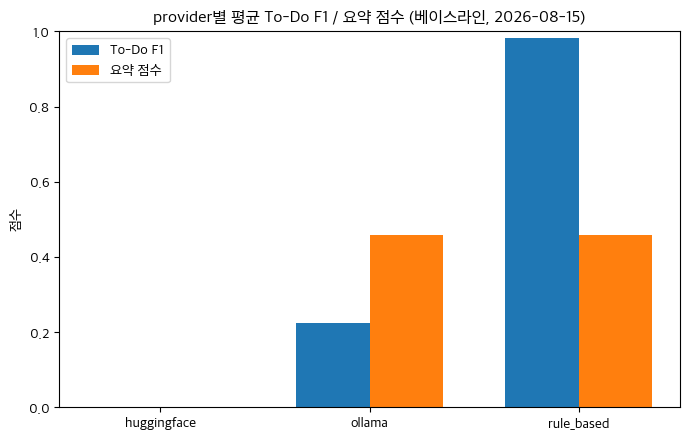

In [6]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 한글 라벨이 네모(tofu)로 깨지지 않도록 macOS 기본 한글 폰트를 명시적으로 등록한다.
# AppleGothic.ttf는 이 macOS 버전에 실제로 없어(FileNotFoundError로 확인) 대신
# 실재를 확인한 AppleSDGothicNeo.ttc를 쓴다.
_KOREAN_FONT_PATH = "/System/Library/Fonts/AppleSDGothicNeo.ttc"
if Path(_KOREAN_FONT_PATH).exists():
    fm.fontManager.addfont(_KOREAN_FONT_PATH)
    plt.rcParams["font.family"] = fm.FontProperties(fname=_KOREAN_FONT_PATH).get_name()
plt.rcParams["axes.unicode_minus"] = False

providers = [report_hf.provider, report_ollama.provider, report_rule.provider]
mean_f1 = [report_hf.mean_f1, report_ollama.mean_f1, report_rule.mean_f1]
mean_summary = [report_hf.mean_summary_score, report_ollama.mean_summary_score, report_rule.mean_summary_score]

x = range(len(providers))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar([i - width / 2 for i in x], mean_f1, width, label="To-Do F1")
ax.bar([i + width / 2 for i in x], mean_summary, width, label="요약 점수")
ax.set_xticks(list(x))
ax.set_xticklabels(providers)
ax.set_ylim(0, 1)
ax.set_ylabel("점수")
ax.set_title("provider별 평균 To-Do F1 / 요약 점수 (베이스라인, 2026-08-15)")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "provider_comparison.png", dpi=150)
plt.show()

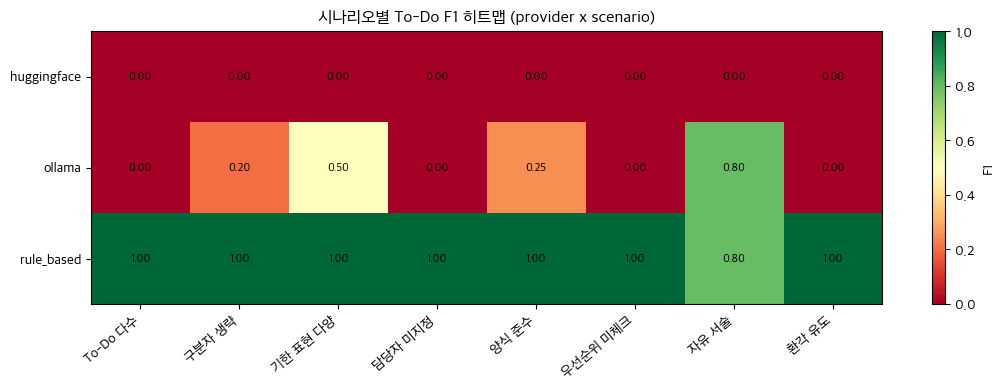

In [7]:
import numpy as np

scenario_order = sorted(df["scenario"].unique())
provider_order = [report_hf.provider, report_ollama.provider, report_rule.provider]

heat = (
    df.pivot_table(index="provider", columns="scenario", values="f1", aggfunc="mean")
    .reindex(index=provider_order, columns=scenario_order)
)

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(heat.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(scenario_order)))
ax.set_xticklabels(scenario_order, rotation=40, ha="right")
ax.set_yticks(range(len(provider_order)))
ax.set_yticklabels(provider_order)
for i in range(len(provider_order)):
    for j in range(len(scenario_order)):
        value = heat.values[i, j]
        text = "-" if np.isnan(value) else f"{value:.2f}"
        ax.text(j, i, text, ha="center", va="center", fontsize=8)
ax.set_title("시나리오별 To-Do F1 히트맵 (provider x scenario)")
fig.colorbar(im, ax=ax, label="F1")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "scenario_heatmap.png", dpi=150)
plt.show()

In [8]:
csv_path = OUTPUT_DIR / "baseline_20260815.csv"
df.to_csv(csv_path, index=False, encoding="utf-8-sig")
print("저장:", csv_path, f"({len(df)} rows)")

저장: /Users/tina/Project/WorkFlow_AI/output/meeting_eval/baseline_20260815.csv (36 rows)


## 관찰 결과 (2026-08-15 실측)

**1. provider별 평균 To-Do F1 / 요약 점수**

| provider | 평균 F1 | 평균 요약 점수 |
|---|---|---|
| huggingface | 0.000 | 0.000 |
| ollama | 0.225 | 0.458 |
| rule_based | 0.983 | 0.458 |

규칙 기반이 To-Do F1에서 압도적으로 높다. LLM(Ollama)이 자유 서술을 놓치지 않고 잡아내긴 하지만(자유 서술 F1=0.80), 정형화된 액션 아이템 칸을 그대로 파싱하는 규칙 기반을 F1로는 못 따라간다 — 규칙 기반은 액션 아이템 섹션이 있으면 그 줄을 결정적으로 파싱하기 때문(`build_todos_from_action_items`). 참고로 Ollama는 온도 0.1이라도 케이스마다 조금씩 다른 결과를 낸다 — 이 노트북을 두 번 실행했더니 환각 유도 시나리오 F1이 1.00 → 0.00으로 바뀌었다(전체 평균 F1도 0.317 → 0.225로 이동). 절대 F1보다 "규칙 기반 >> Ollama"라는 순위 자체가 더 안정적인 신호다.

**2. 3단계 폴백이 실제로 도달하는 provider**

HuggingFace는 12/12건 전부 `401 Unauthorized`로 실패했다. `App/.env`의 `HF_TOKEN`이 코드 문제가 아니라 토큰 자체가 무효하다는 것을 `huggingface.co/api/whoami-v2`에 대한 직접 curl 호출로도 확인했다(`{"error":"Invalid username or password."}`). 즉 지금 이 환경에서 실제 요청은 HF에서 즉시 실패하고 Ollama로 넘어간다. Ollama는 12건 중 11건 성공(1건은 `many-01`에서 모델이 JSON 문자열을 마치지 못해 파싱 실패 — 두 번의 실행 모두 같은 케이스에서 재현됨). 결론: **현재 환경의 폴백은 HuggingFace를 건너뛰고 Ollama에 도달한다.** 다만 이건 로컬에 Ollama가 떠 있기 때문이며, Ollama가 없는 배포 환경이라면 두 단계 모두 실패해 규칙 기반까지 떨어질 수 있다 — 아래 "우려" 참고.

**3. 구분자 생략(nosep) vs 양식 준수(formal) — 담당자/기한 정확도**

| scenario | provider | assignee_accuracy | due_date_accuracy |
|---|---|---|---|
| 구분자 생략 | ollama | 0.0 | 0.5 |
| 구분자 생략 | rule_based | 1.0 | 1.0 |
| 양식 준수 | ollama | 0.0 | 0.0 |
| 양식 준수 | rule_based | 1.0 | 1.0 |

**premise가 이 데이터에서는 성립하지 않는다.** rule_based는 두 시나리오에서 완전히 동일(1.0/1.0) — 구분자 생략이 규칙 기반 파서에 전혀 영향을 주지 않았다. ollama는 담당자 정확도가 둘 다 0.0으로 동률이고, 기한 정확도는 오히려 **구분자 생략(0.5)이 양식 준수(0.0)보다 높다** — premise와 반대 방향이다. 케이스가 시나리오당 2건뿐이라 통계적으로 약하지만, 방향 자체가 premise를 지지하지 않으므로 "구분자 생략이 더 나쁘다"를 전제로 한 후속 작업은 이 숫자로는 근거가 없다. 재확인이 필요하다.

**4. fallback_matched(제목 겹침 매칭) 건수**

| provider | fallback_matched 합계 |
|---|---|
| huggingface | 0 |
| ollama | 2 |
| rule_based | 0 |

HF는 애초에 매칭이 0건(전부 실패). rule_based는 액션 아이템을 그대로 파싱해 근거 문장이 항상 채워지므로 폴백이 필요 없다. Ollama만 근거 문장 없이 제목 겹침으로 매칭된 건이 있다 — Ollama LLM 경로가 만들어내는 To-Do의 근거 문장 품질이 상대적으로 떨어진다는 신호.

**5. 심사기가 실제로 내놓은 원문 답변 (R5)**

`['아니오', '예']` — 두 값 모두 `_AFFIRMATIVE` 판정 로직이 정확히 처리하는 정규형 표현이다. "네"/"예요" 같은 변형은 관측되지 않았다. 다만 이 결과는 심사 백엔드를 Ollama(qwen2.5:1.5b)로 바꿔서 나온 것이라 원래 계획한 HF 모델의 답변 분포와 다를 수 있다 — HF 토큰이 살아나면 재확인이 필요하다.

**우려 사항**

- `App/.env`의 `HF_TOKEN`이 무효하다(401). 회의록 분석 기능 자체가 지금 프로덕션에서도 이 토큰을 쓰고 있다면 HF 경로는 항상 실패하고 있을 가능성이 있다 — 별도로 확인이 필요하다.
- 브리프는 HF 클라이언트로 감싼 `judge_ask`를 지정했지만, 토큰이 죽어 있어 로컬 Ollama(`qwen2.5:1.5b`, 분석에 쓰는 모델과 동일)로 대체했다. 심사 모델이 분석 모델과 같아 자기 평가 편향 가능성이 있다는 점을 감안해서 봐야 한다.
- `MEETING_ANALYSIS_TIMEOUT_SECONDS`를 기본 20초에서 90초로 늘려서 측정했다(콜드 로드 시간 확보 목적). 실제 서비스가 20초 타임아웃을 그대로 쓴다면, 이 노트북이 관측한 Ollama 성공률(11/12)보다 실제 서비스의 성공률이 낮을 수 있다.
- Ollama 결과는 온도 0.1에서도 실행마다 조금씩 흔들린다(위 1번 참고). 이 노트북의 절대 숫자를 "고정된 진실"로 쓰지 말고, 재실행해도 크게 안 변하는 순위·방향성 위주로 판단할 것.
- nosep vs formal 비교(질문 3)는 시나리오당 2건뿐이라 표본이 매우 작다. "구분자 생략이 더 나쁘다"는 다음 작업의 전제를 재검토하거나, 케이스를 늘려 재측정할 것을 권장한다.